<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>What changed in COSMIC versions?</p>
</div>

In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.interpolate import interp1d
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

# Load data

In [3]:
files = ["fiducial"]
labels = ["thing"]
colours = ["#333"]

pops, latest_data = helpers.load_postprocessed_pops(files, labels, colours, folder='/mnt/ceph/users/twagg/underworld/postprocessed/')
latest = pops[0]
latest_data = latest_data["thing"]

pops, old_data = helpers.load_postprocessed_pops(files, labels, colours, folder='/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-0/postprocessed/')
old = pops[0]
old_data = old_data["thing"]

files = ["fiducial_processed"]
pops, very_old_data = helpers.load_postprocessed_pops(files, labels, colours, folder='/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-m1/postprocessed/')
very_old = pops[0]
very_old_data = very_old_data["thing"]

Loading post-processed data for thing from fiducial
Loading post-processed data for thing from fiducial
Loading post-processed data for thing from fiducial_processed


In [4]:
latest_data["mass_binaries"] / old_data["mass_binaries"]

np.float64(1.0017752262388497)

In [5]:
latest_data["n_BH"] / old_data["n_BH"], latest_data["n_BH"], old_data["n_BH"], very_old_data["n_BH"]

(0.9722862610372781, 1806749, 1858248, 1926484)

In [8]:
for d in [latest_data, old_data, very_old_data]:
    print(d["n_BH"], d["mass"]["BH"].sum(), d["n_BH"] / latest_data["n_BH"], d["mass"]["BH"].sum() / latest_data["mass"]["BH"].sum())

1806749 15734264.597143697 1.0 1.0
1858248 16992395.628097393 1.028503682581255 1.0799612224127775
1926484 17685808.480878472 1.0662709651423634 1.1240314646856167


In [6]:
latest_data["n_NS"] / old_data["n_NS"]

1.0675494413970092

# Interrogate singles

In [109]:
from cosmic.output import load_initC
old_singles_initC = load_initC("/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-0/singles/singles_part0.h5", "initC")
new_singles_initC = load_initC("/mnt/ceph/users/twagg/underworld/sims/singles/singles_part0.h5", "initial_binaries")

In [112]:
old_bpp = pd.read_hdf("/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-0/singles/singles_part0.h5", "bpp")

In [121]:
(old_bpp.drop_duplicates(subset="bin_num", keep="last")["kstar_1"] == 14).sum() + (old_bpp.drop_duplicates(subset="bin_num", keep="last")["kstar_2"] == 14).sum()

np.int64(41399)

In [110]:
from cosmic.evolve import Evolve

old_singles_initC.loc[:, "fryer_fmix"] = 1.0
old_singles_initC.loc[:, "fryer_mcrit_nsbh"] = 5.0
old_singles_initC.loc[:, "smt_periastron_check"] = 0
old_singles_initC.loc[:, "stellar_engine"] = "sse"
old_singles_initC.loc[:, "path_to_tracks"] = ""
old_singles_initC.loc[:, "path_to_he_tracks"] = ""

old_singles_initC.loc[:, "alpha1_0"] = old_singles_initC["alpha1"]
old_singles_initC.loc[:, "alpha1_1"] = old_singles_initC["alpha1"]
old_singles_initC.loc[:, "acc_lim_0"] = old_singles_initC["acc_lim"]
old_singles_initC.loc[:, "acc_lim_1"] = old_singles_initC["acc_lim"]

old_singles_initC.drop(columns=["alpha1", "acc_lim"], inplace=True)

bpp, bcm, initC, kick_info = Evolve.evolve(
    old_singles_initC, nproc=32, progress=True
)

/tmp/ipykernel_2225572/4207532782.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  old_singles_initC.loc[:, "fryer_fmix"] = 1.0

/tmp/ipykernel_2225572/4207532782.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  old_singles_initC.loc[:, "fryer_mcrit_nsbh"] = 5.0

/tmp/ipykernel_2225572/4207532782.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

Evolving: 100%|██████████| 127459/127459 [04:29<00:00, 472.94sys/s]


In [122]:
(bpp.drop_duplicates(subset="bin_num", keep="last")["kstar_1"] == 14).sum() + (bpp.drop_duplicates(subset="bin_num", keep="last")["kstar_2"] == 14).sum()

np.int64(41400)

In [111]:
bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,RRLO_1,RRLO_2,evol_type,aj_1,aj_2,tms_1,tms_2,massc_he_layer_1,massc_he_layer_2,massc_co_layer_1,massc_co_layer_2,rad_1,rad_2,mass0_1,mass0_2,lum_1,lum_2,teff_1,teff_2,radc_1,radc_2,menv_1,menv_2,renv_1,renv_2,omega_spin_1,omega_spin_2,B_1,B_2,bacc_1,bacc_2,tacc_1,tacc_2,epoch_1,epoch_2,bhspin_1,bhspin_2,bin_num
0,0.000000,27.639839,11.005008,1,1,3.064190e+14,1.000000e+20,0.228058,7.648696e-14,6.535581e-14,1,0.000000,0.000000,5.506922e+00,1.849749e+01,0.000000,0.000000,0.000000,0.000000,8.327489,4.679345,27.639839,11.005008,1.020814e+05,7904.084014,35912.800031,25272.019732,0.000000,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,1.244753e+03,2288.601830,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0
0,5.662573,23.987301,10.939616,2,1,3.390500e+14,1.224300e+20,0.228058,1.989125e-13,6.624672e-14,2,6.250881,5.704164,6.250881e+00,1.870114e+01,7.017718,0.000000,0.000000,0.000000,23.333452,5.434098,23.987301,10.939616,2.001125e+05,9363.253059,25386.258001,24465.976833,0.752289,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,7.293224e+01,1619.070873,0.000000e+00,0.0,0.0,0.0,0.0,0.0,-0.588308,-0.041591,0.0,0.0,0
0,5.672300,23.899923,10.939429,4,1,3.399022e+14,1.230462e+20,0.228058,1.227367e-11,6.603898e-14,2,6.260608,5.714070,6.250881e+00,1.870173e+01,7.158065,0.000000,0.000000,0.000000,1442.340892,5.435691,23.987301,10.939429,1.849150e+05,9366.579321,3165.765062,24464.565223,0.761617,0.000000,1.326786e+01,1.000000e-10,1.360153e+03,1.000000e-10,1.387237e-02,1617.904719,0.000000e+00,0.0,0.0,0.0,0.0,0.0,-0.588308,-0.041770,0.0,0.0,0
0,6.110545,8.459432,10.930877,7,1,6.137570e+14,4.001976e+20,0.228058,5.541813e-15,2.897580e-14,2,0.443664,6.160861,7.274687e-01,1.872867e+01,4.995164,0.000000,3.464268,0.000000,0.937238,5.509081,8.459432,10.930877,1.309004e+05,9520.079703,113914.740400,24400.020730,0.000000,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,3.038709e-10,1565.397670,0.000000e+00,0.0,0.0,0.0,0.0,0.0,5.666881,-0.050316,0.0,0.0,0
0,6.430198,6.315255,10.924450,8,1,6.903936e+14,5.063518e+20,0.228058,3.973788e-15,2.444773e-14,2,0.925041,6.487365,9.250405e-01,1.874897e+01,2.284201,0.000000,4.031054,0.000000,0.704390,5.564745,6.315255,10.924450,9.186506e+04,9636.592304,120268.110105,24351.619514,0.000070,0.000000,1.000000e-10,1.000000e-10,1.000000e-10,1.000000e-10,8.823459e-10,1527.133968,0.000000e+00,0.0,0.0,0.0,0.0,0.0,5.505157,-0.057167,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317441,152.011832,1.260782,4.016373,13,4,-1.000000e+00,-1.000000e+00,-1.000000,1.000000e-04,1.000000e-04,2,98.792065,152.095162,1.000000e+10,1.509594e+02,0.000000,0.651485,0.000000,0.000000,0.000014,70.701143,7.071471,4.017097,2.393397e-06,1478.575129,60947.973253,4275.798616,0.000014,0.143915,1.000000e-10,3.364887e+00,1.000000e-10,7.055723e+01,2.597443e+08,4.162018,3.656683e+11,0.0,0.0,0.0,0.0,0.0,53.219767,-0.083331,0.0,0.0,317441
317441,172.422027,1.260782,3.949067,13,5,-1.000000e+00,-1.000000e+00,-1.000000,1.000000e-04,1.000000e-04,2,119.202260,172.505358,1.000000e+10,1.509594e+02,0.000000,0.554405,0.000000,0.603871,0.000014,80.273156,7.071471,4.017097,1.643955e-06,1917.774681,55485.314889,4282.366537,0.000014,0.228372,1.000000e-10,2.790791e+00,1.000000e-10,8.004478e+01,2.396843e+08,3.363983,3.631890e+11,0.0,0.0,0.0,0.0,0.0,53.219767,-0.083331,0.0,0.0,317441
317441,173.250447,1.260782,3.901566,13,6,-1.000000e+00,-1.000000e+00,-1.000000,1.000000e-04,1.000000e-04,2,120.030681,173.333778,1.000000e+10,1.509594e+02,0.000000,0.000000,0.000000,0.957641,0.000014,422.629189,7.071471,4.017097,1.621341e-06,19234.919459,55293.510725,3321.333299,0.000014,0.042668,1.000000e-10,2.943924e+00,1.000000e-10,4.225865e+02,2.389711e+08,0.103068,3.630888e+11,0.0,0.0,0.0,0.0,0.0,53.219767,-0.083331,0.0,0.0,317441
317441,173.

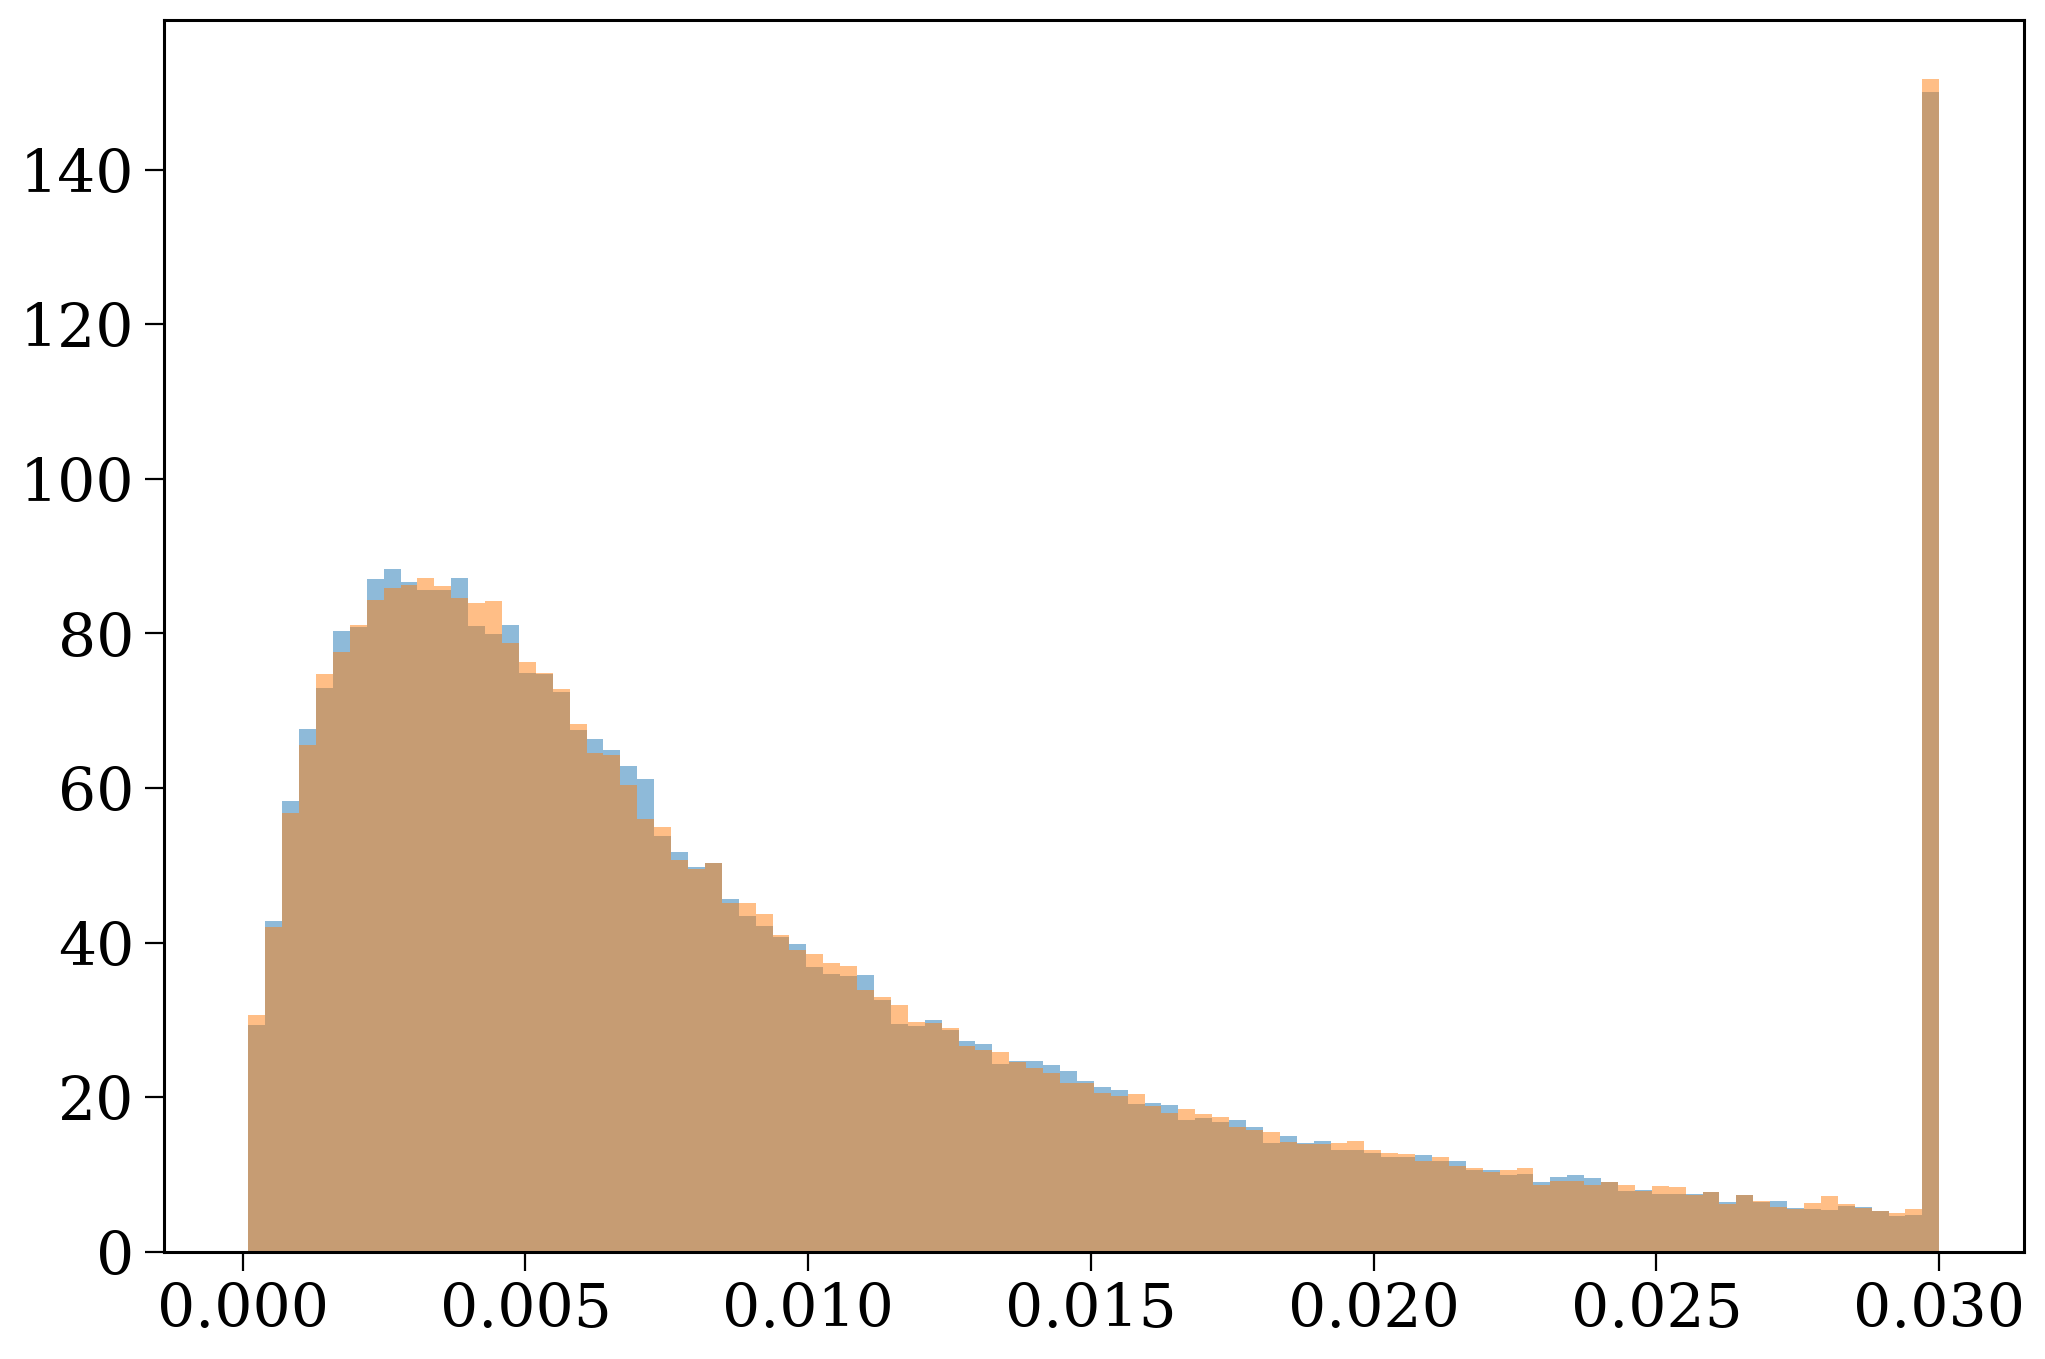

In [95]:
for initC in [old_singles_initC, new_singles_initC]:
    plt.hist(initC["metallicity"], bins=100, density=True, alpha=0.5);

---

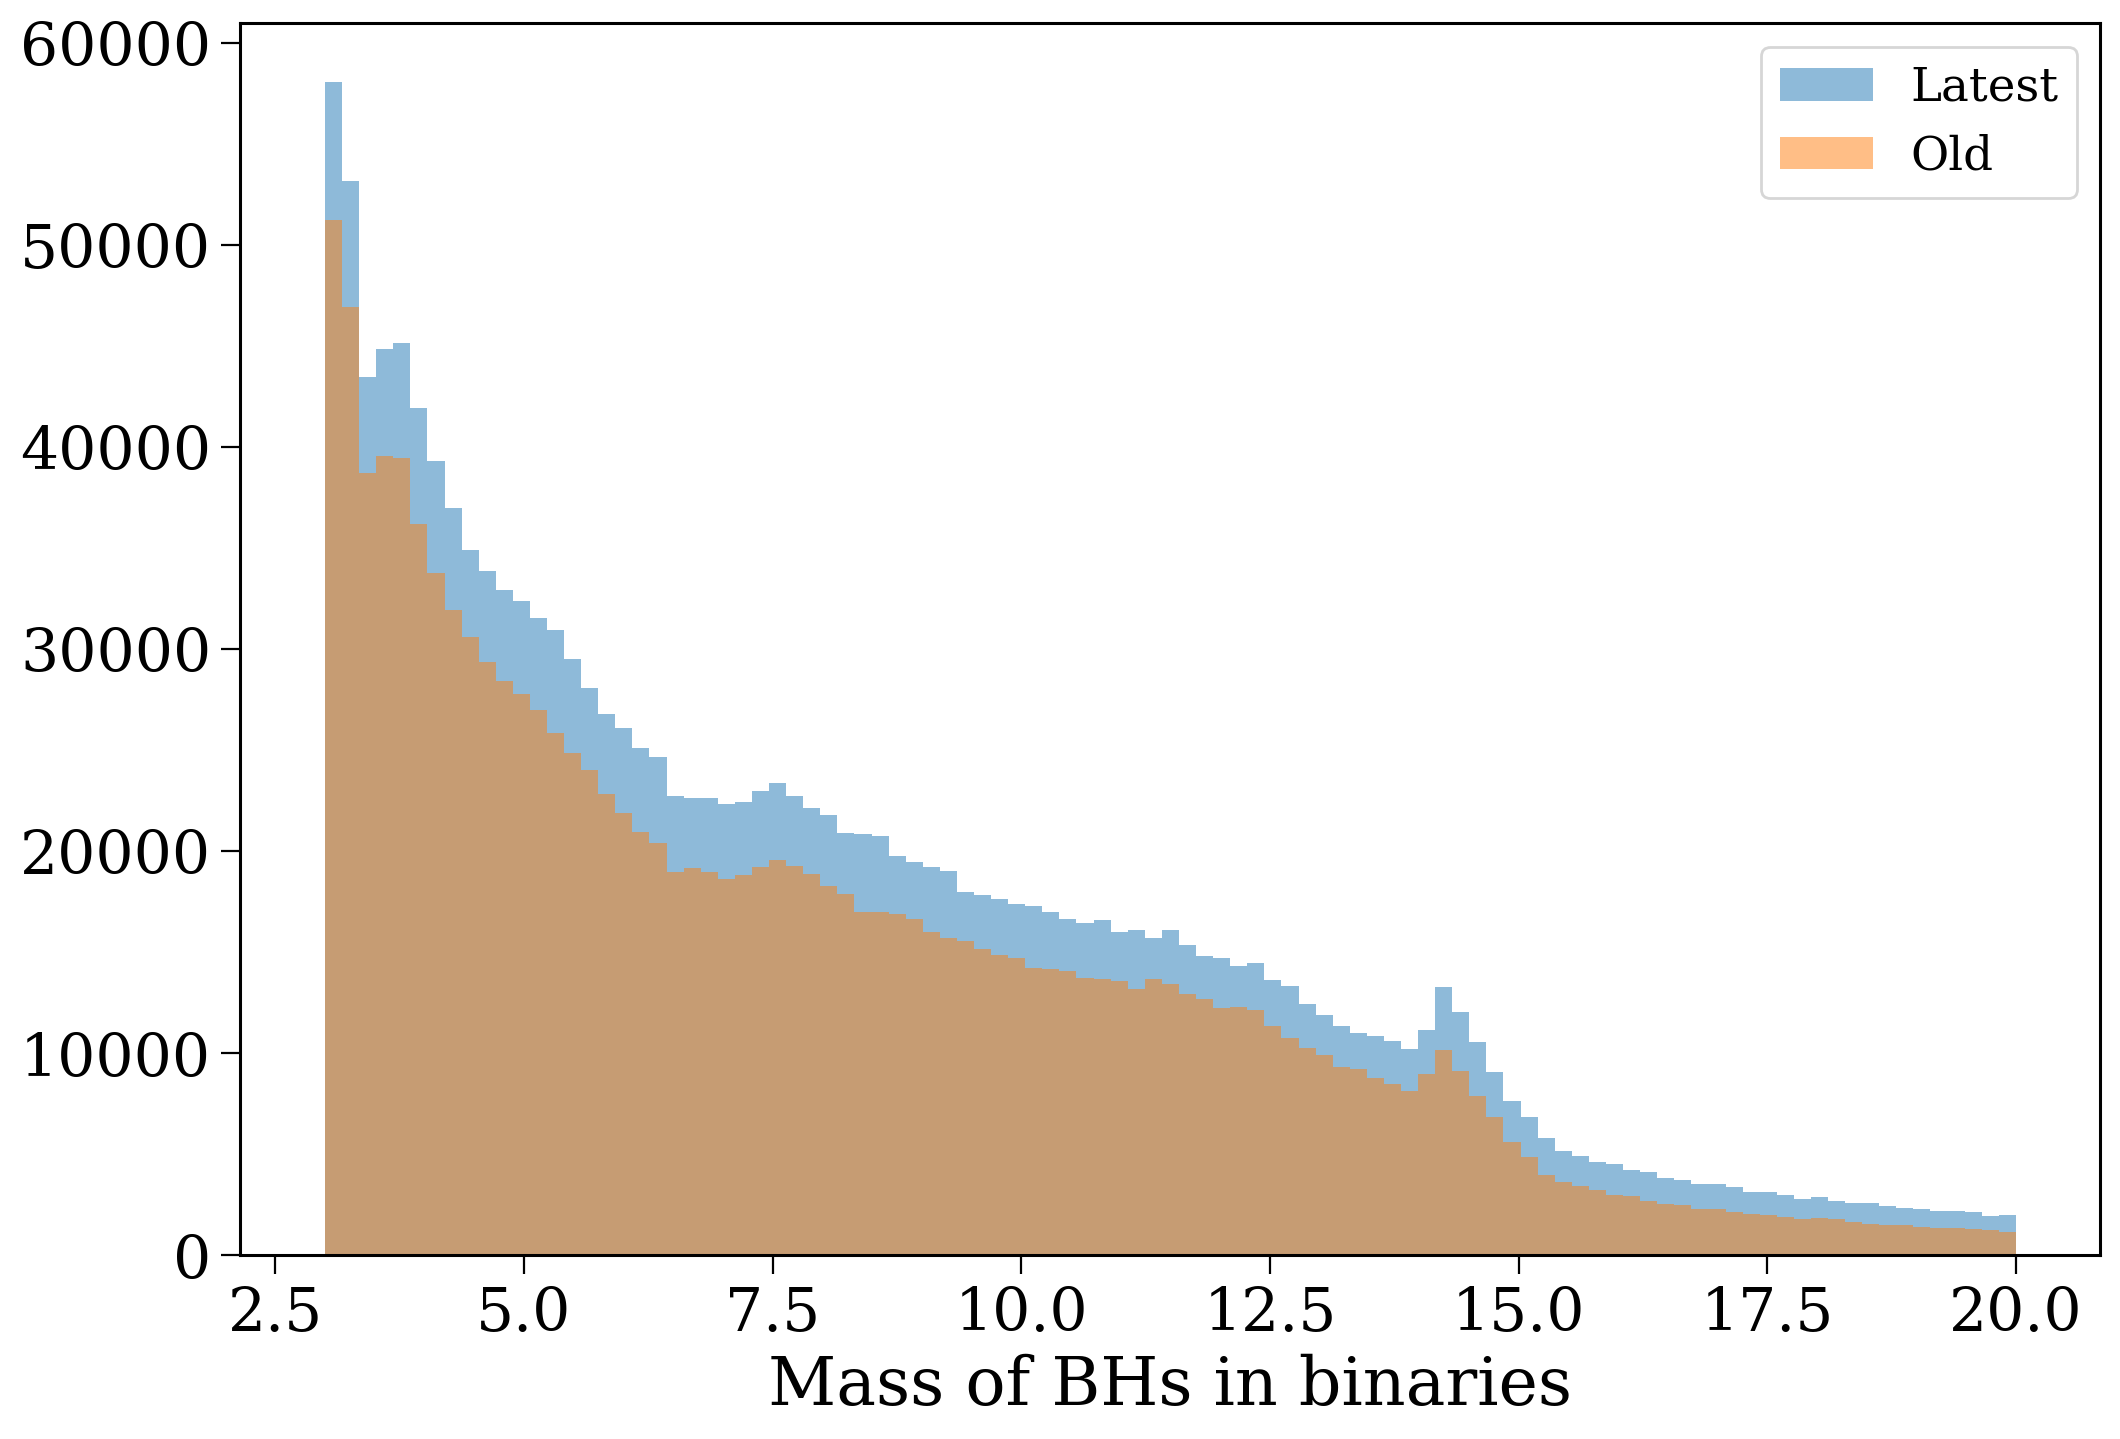

In [83]:
bins = np.linspace(3, 20, 100)

plt.hist(latest_data["mass"]["BH"], bins=bins, alpha=0.5, label="Latest")
plt.hist(old_data["mass"]["BH"], bins=bins, alpha=0.5, label="Old")
plt.xlabel("Mass of BHs in binaries")
plt.legend()

In [182]:
print(plotting.estimate_scale_height_cdf(
    z=latest_data["pos"]["BH"][:, 2][~latest_data["escaped"]["BH"]],
)[0])
print(plotting.estimate_scale_height_cdf(
    z=old_data["pos"]["BH"][:, 2][~old_data["escaped"]["BH"]],
)[0])
print(plotting.estimate_scale_height_cdf(
    z=very_old_data["pos"]["BH"][:, 2][~very_old_data["escaped"]["BH"]],
)[0])

1.018739782928179
1.1187213479982174
1.0193402749291667


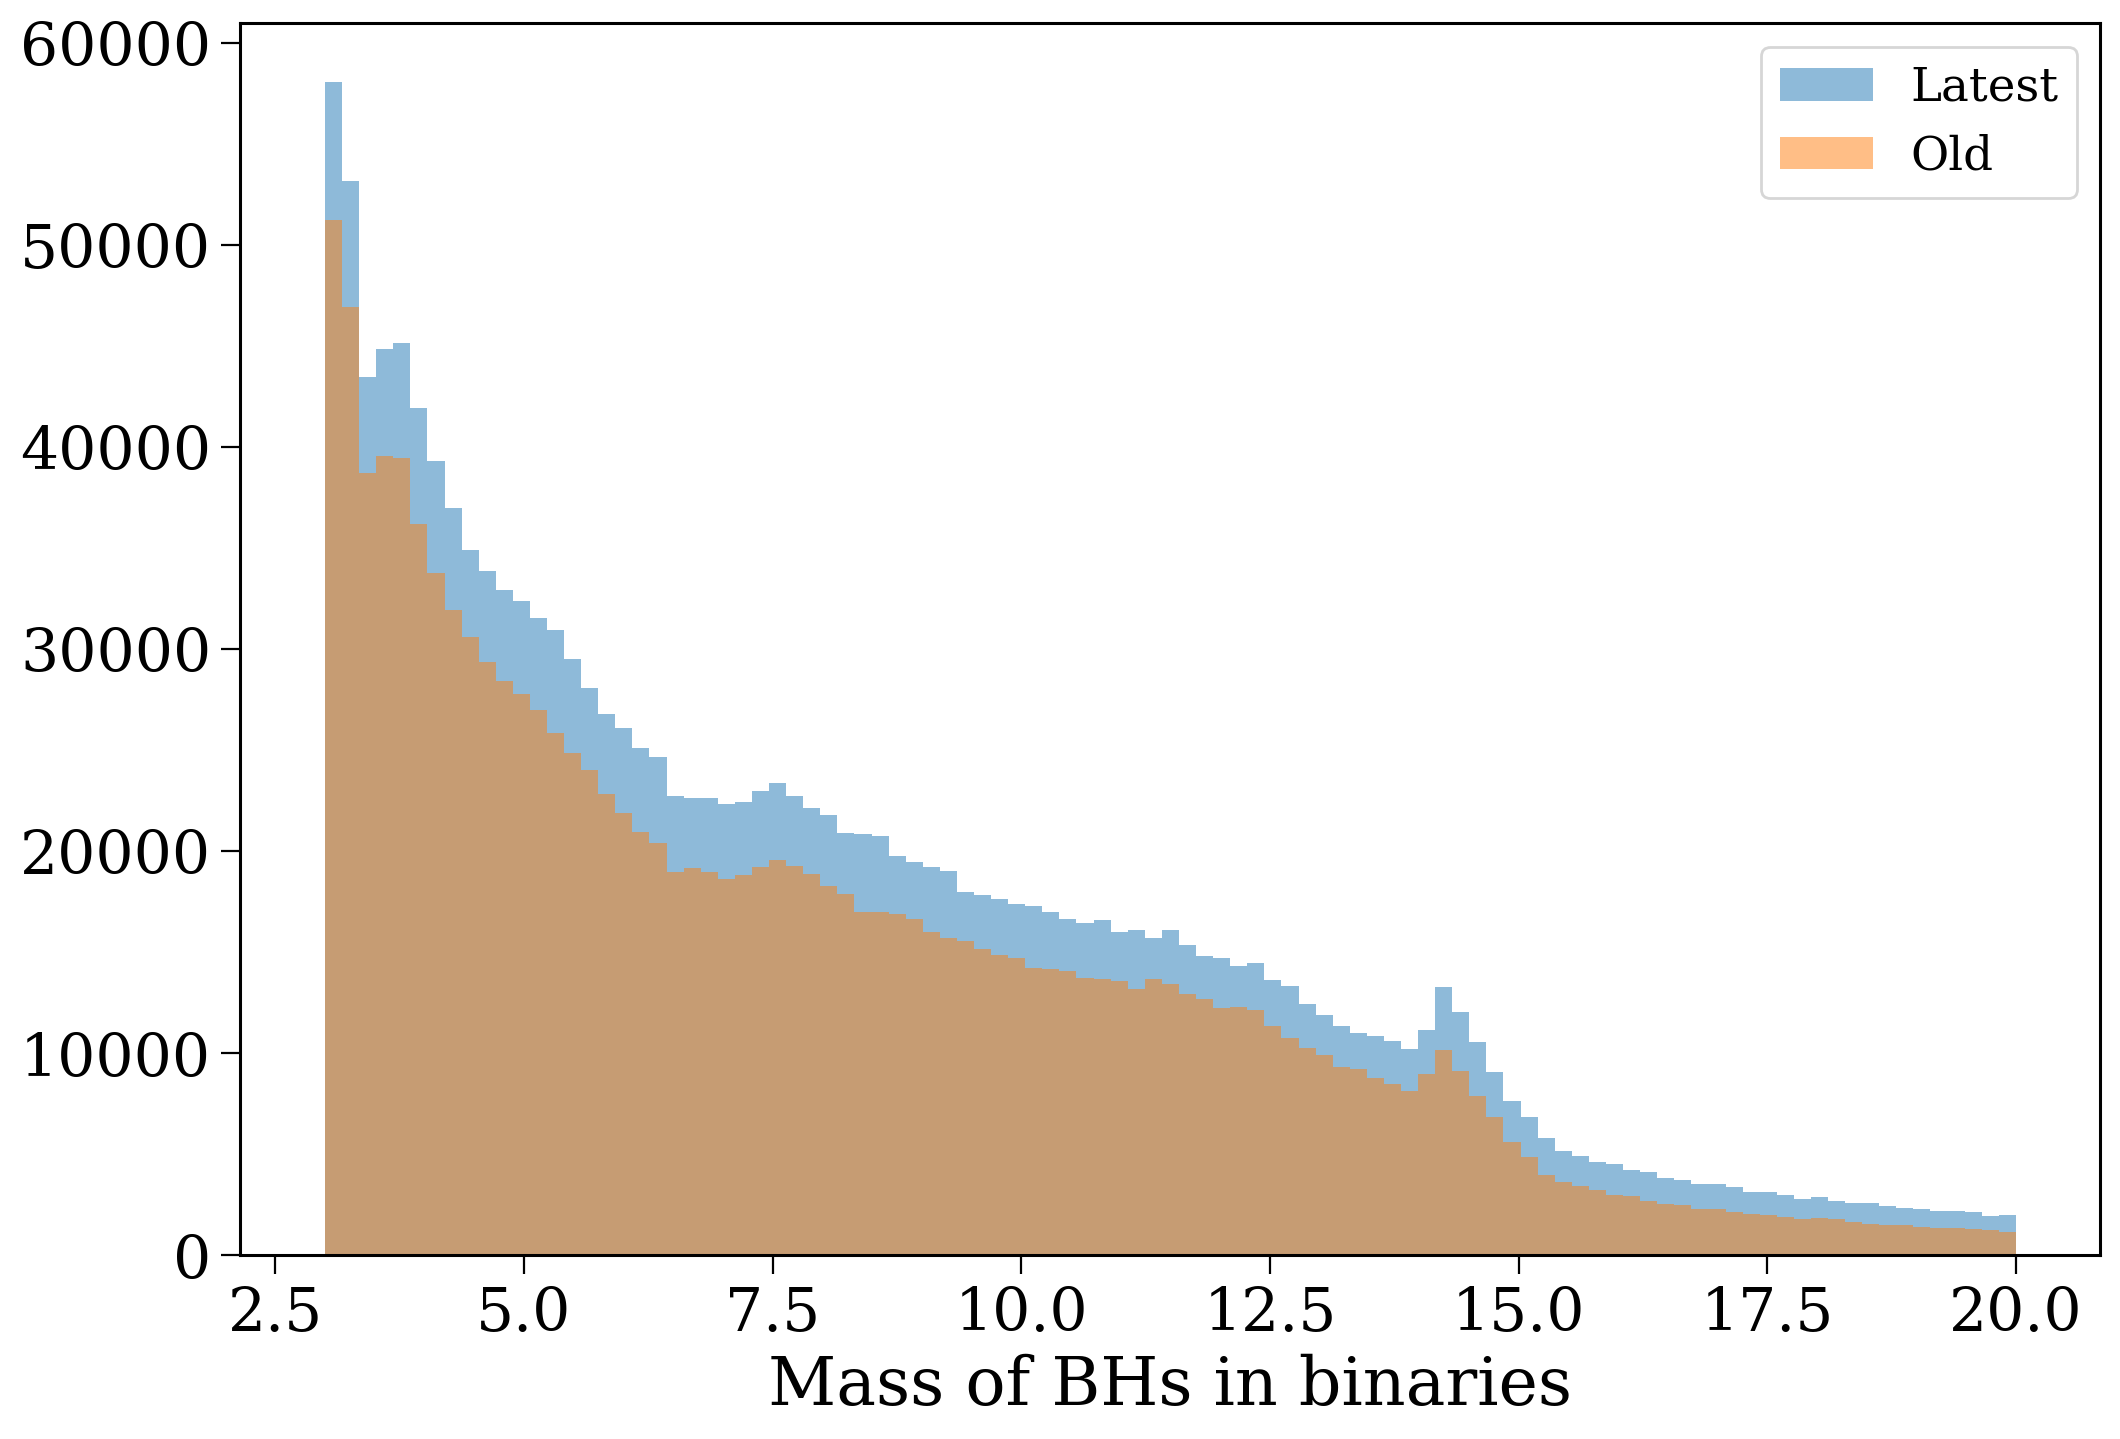

In [46]:
bins = np.linspace(3, 20, 100)

plt.hist(latest_data["mass"]["BH"], bins=bins, alpha=0.5, label="Latest")
plt.hist(old_data["mass"]["BH"], bins=bins, alpha=0.5, label="Old")
plt.xlabel("Mass of BHs in binaries")
plt.legend()

# Templates

In [140]:
very_old_template = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-m1/template/template_part0.h5", parts=[])
old_template = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/COSMIC-3.7.5-qmin-0/template/template_part0.h5", parts=[])
new_template = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/sims/template/template_part0.h5", parts=[])

cogsworth warning: file was saved with gala v1.11.1.dev61 but you are using v1.11.1.dev77
cogsworth warning: file was saved with gala v1.11.1.dev61 but you are using v1.11.1.dev77


In [141]:
very_old_template.initC["mass_2"].min()

np.float64(0.40253404436674717)

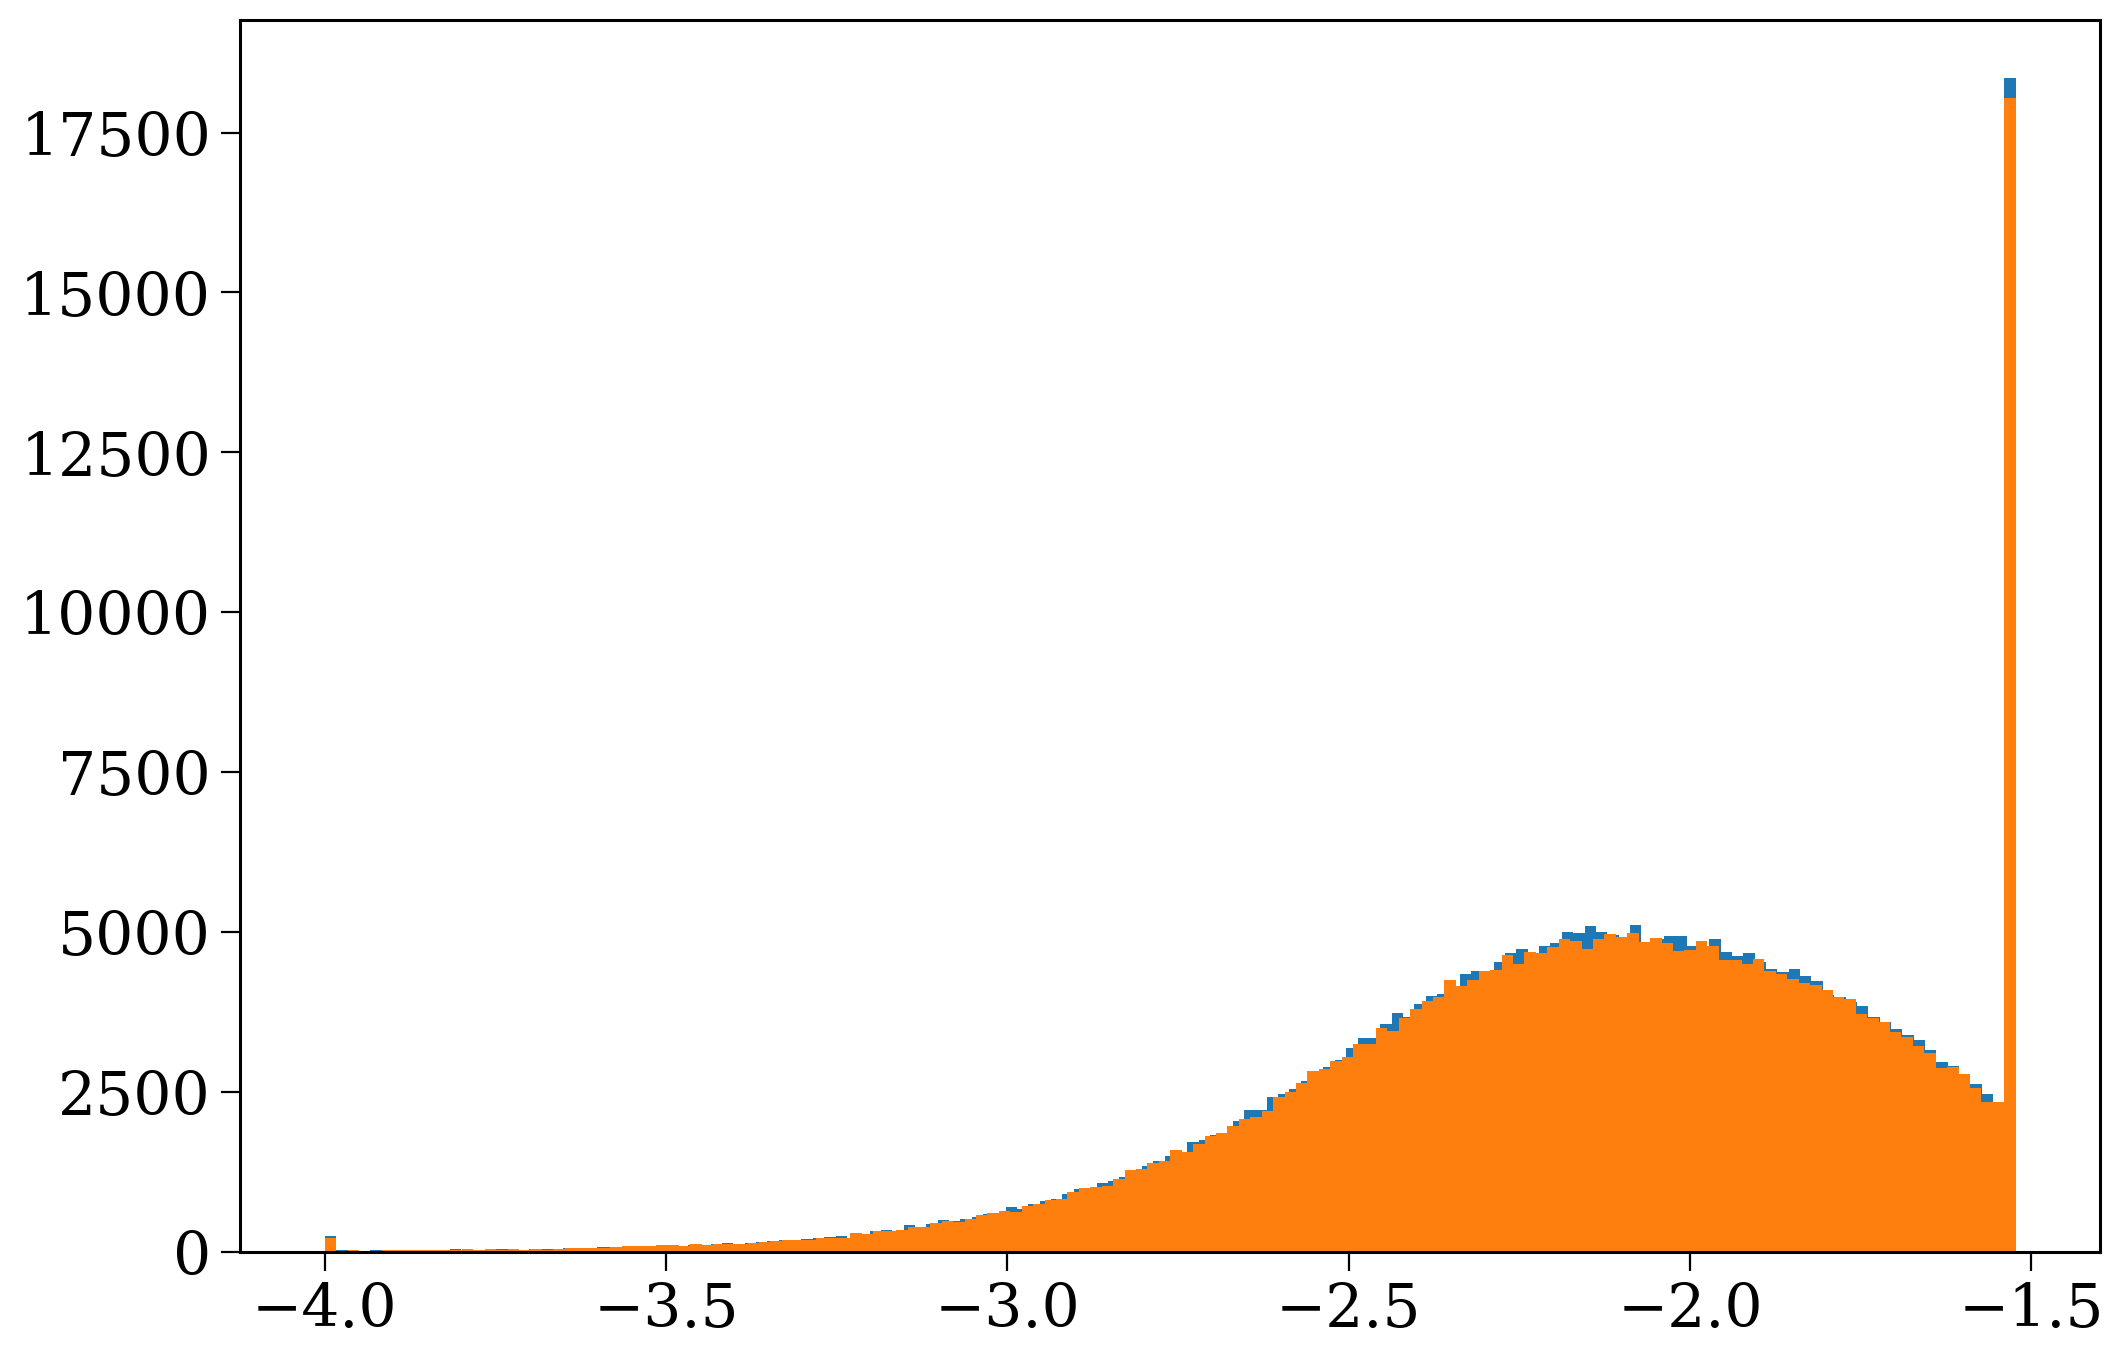

In [65]:
plt.hist(np.log10(old_template.initC["metallicity"]), bins="auto");
plt.hist(np.log10(new_template.initC["metallicity"]), bins="auto");

In [68]:
len(old_template.initC), len(new_template.initC)

(317448, 311424)

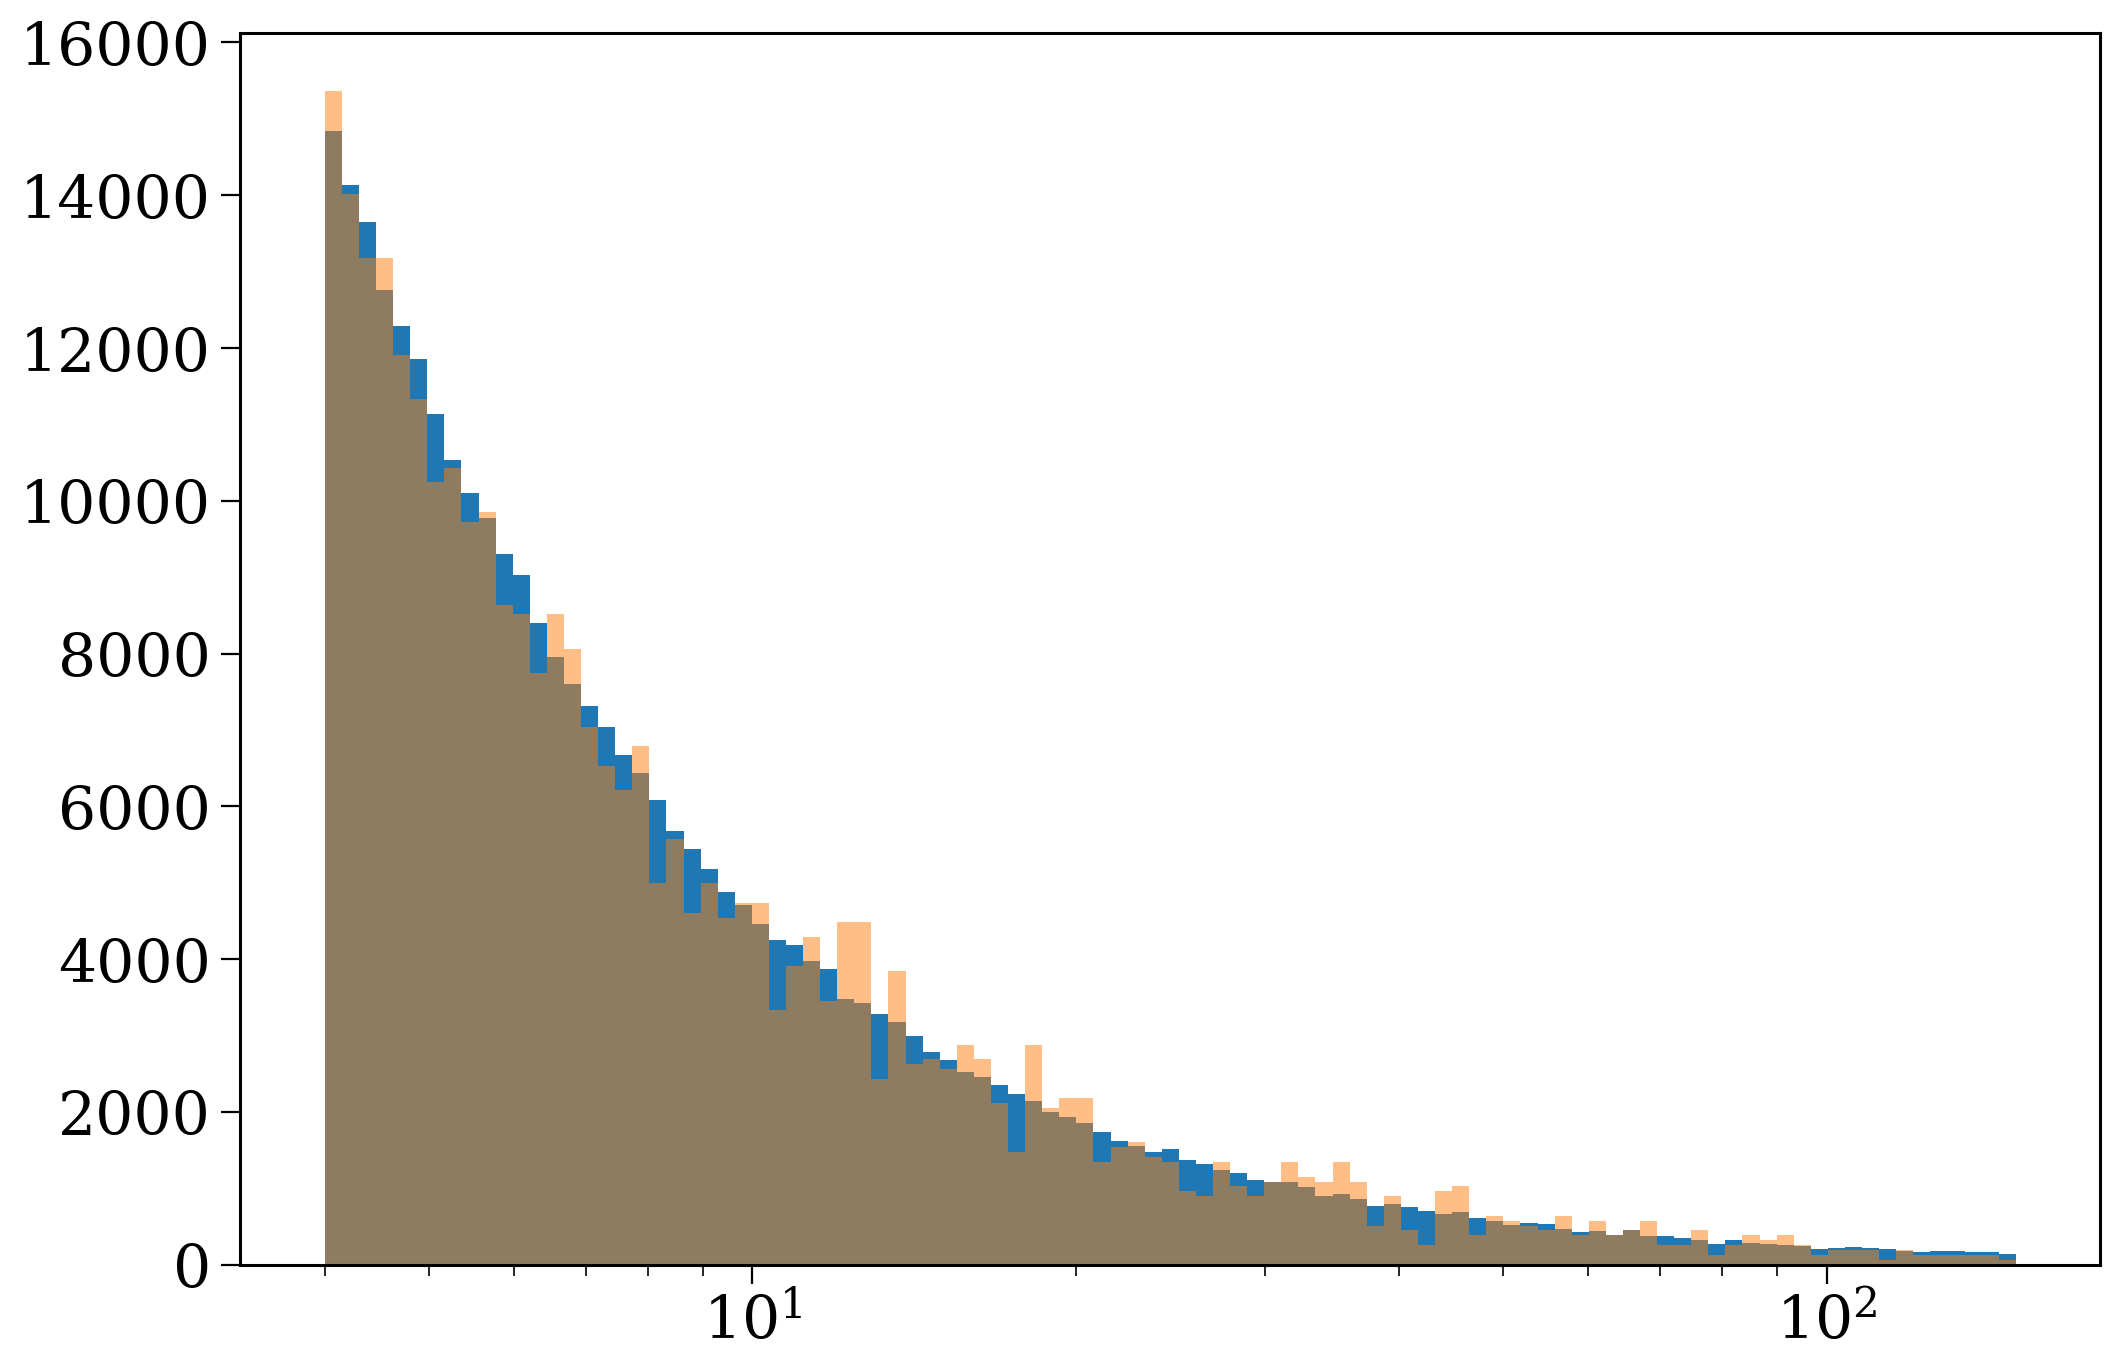

In [75]:
bins = np.geomspace(4, 150, 100)

plt.hist(old_template.initC["mass_1"], bins=bins,);
plt.hist(new_template.initC["mass_1"], bins=bins, alpha=0.5);
plt.xscale("log")

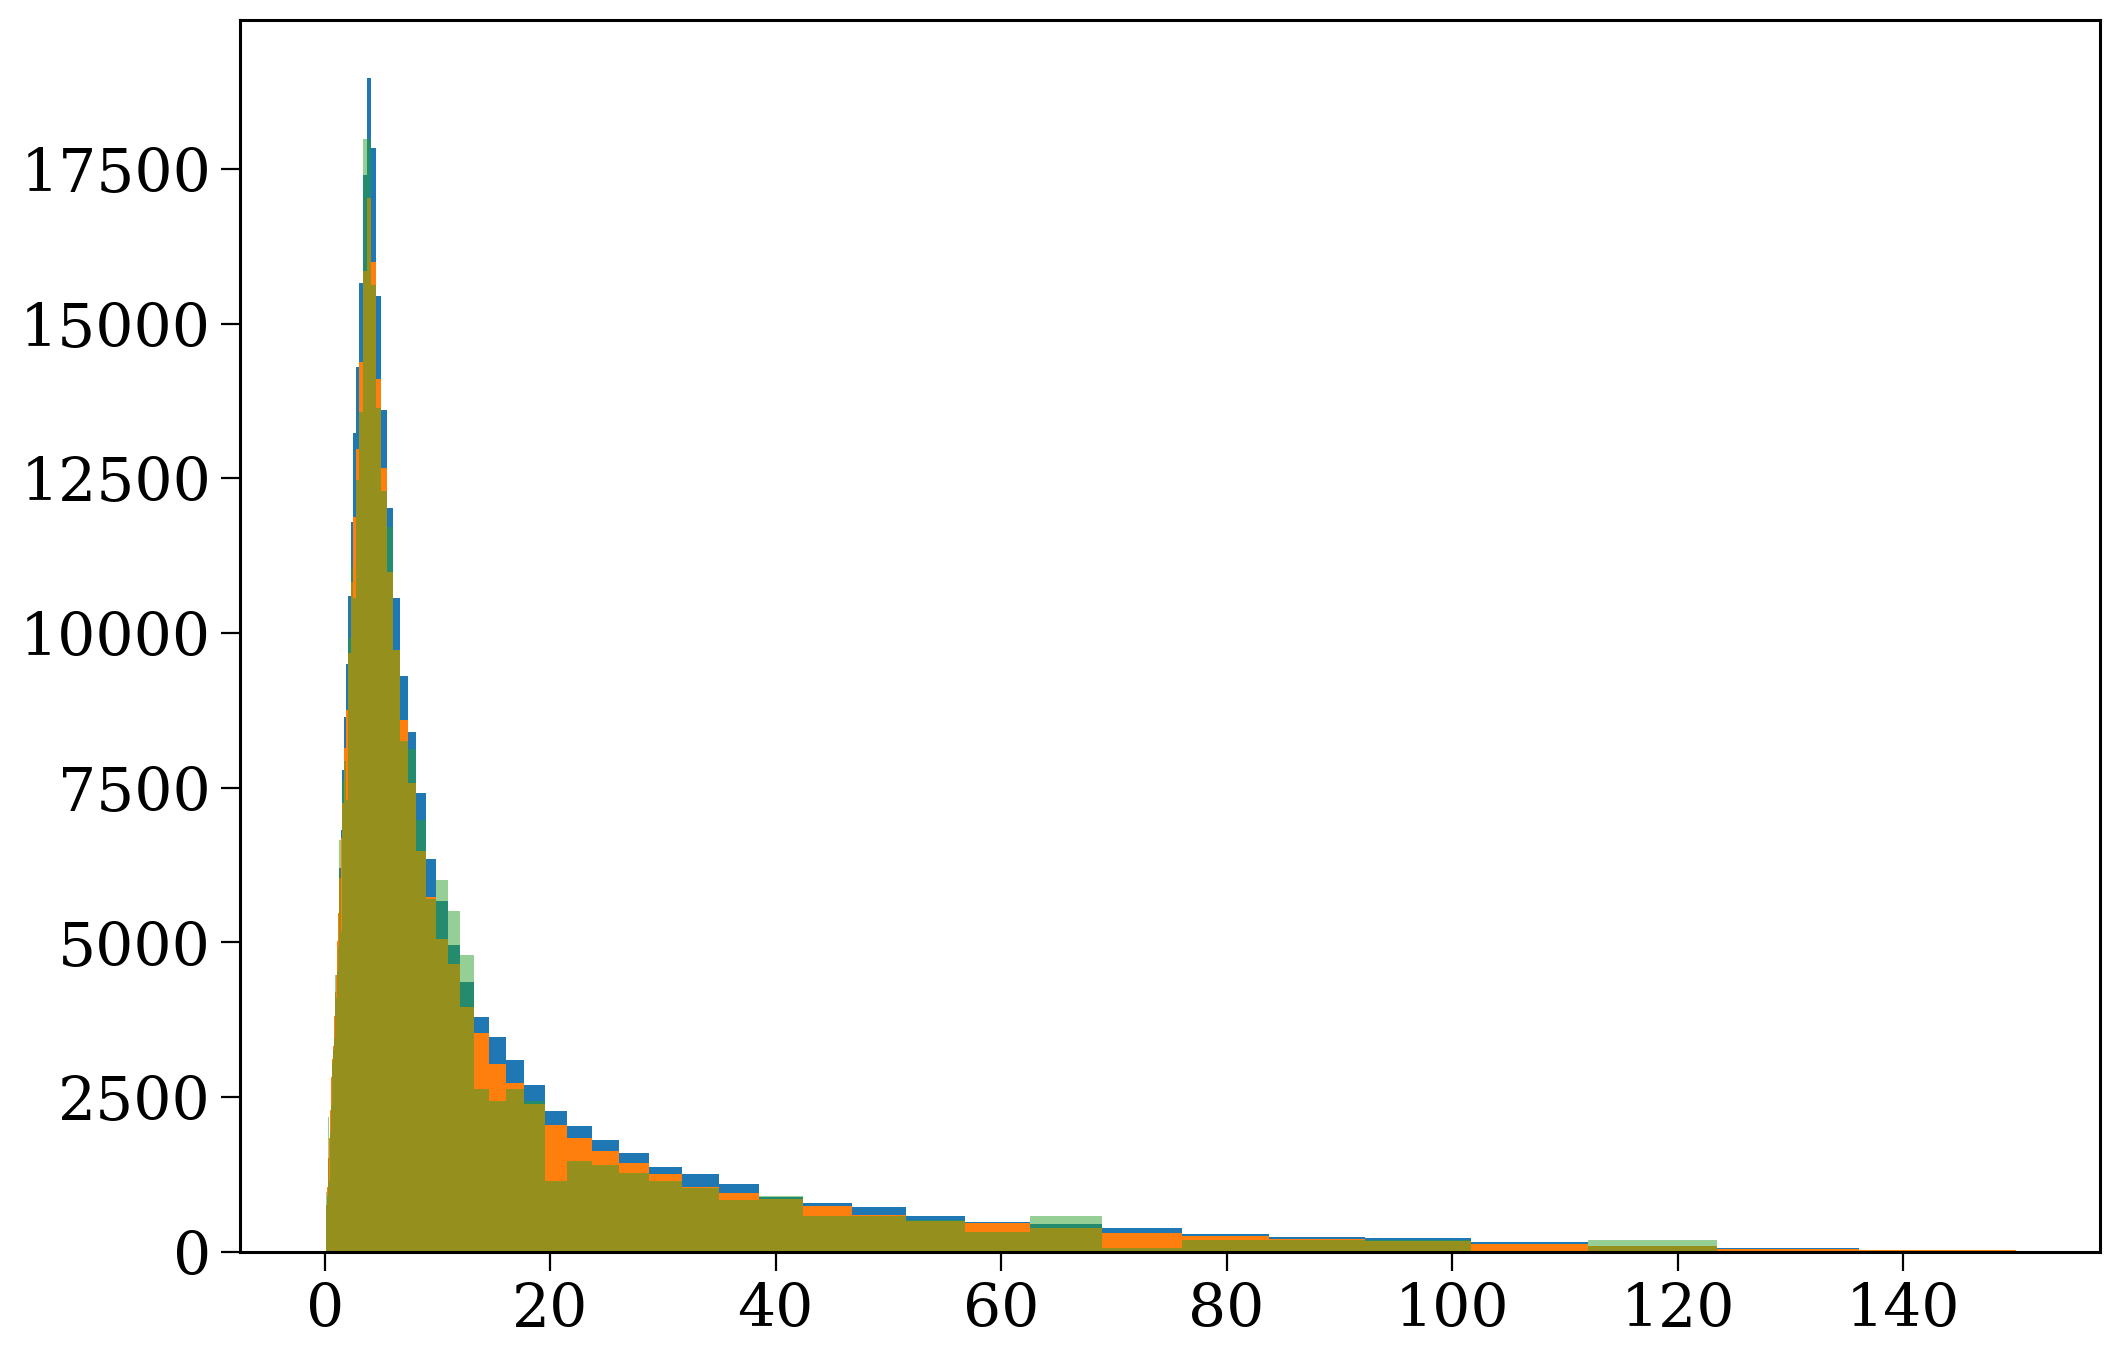

In [168]:
bins = np.geomspace(0.01, 150, 100)

plt.hist(very_old_template.initC["mass_2"], bins=bins,);
plt.hist(old_template.initC["mass_2"], bins=bins,);
plt.hist(new_template.initC["mass_2"], bins=bins, alpha=0.5);
# plt.xscale("log")

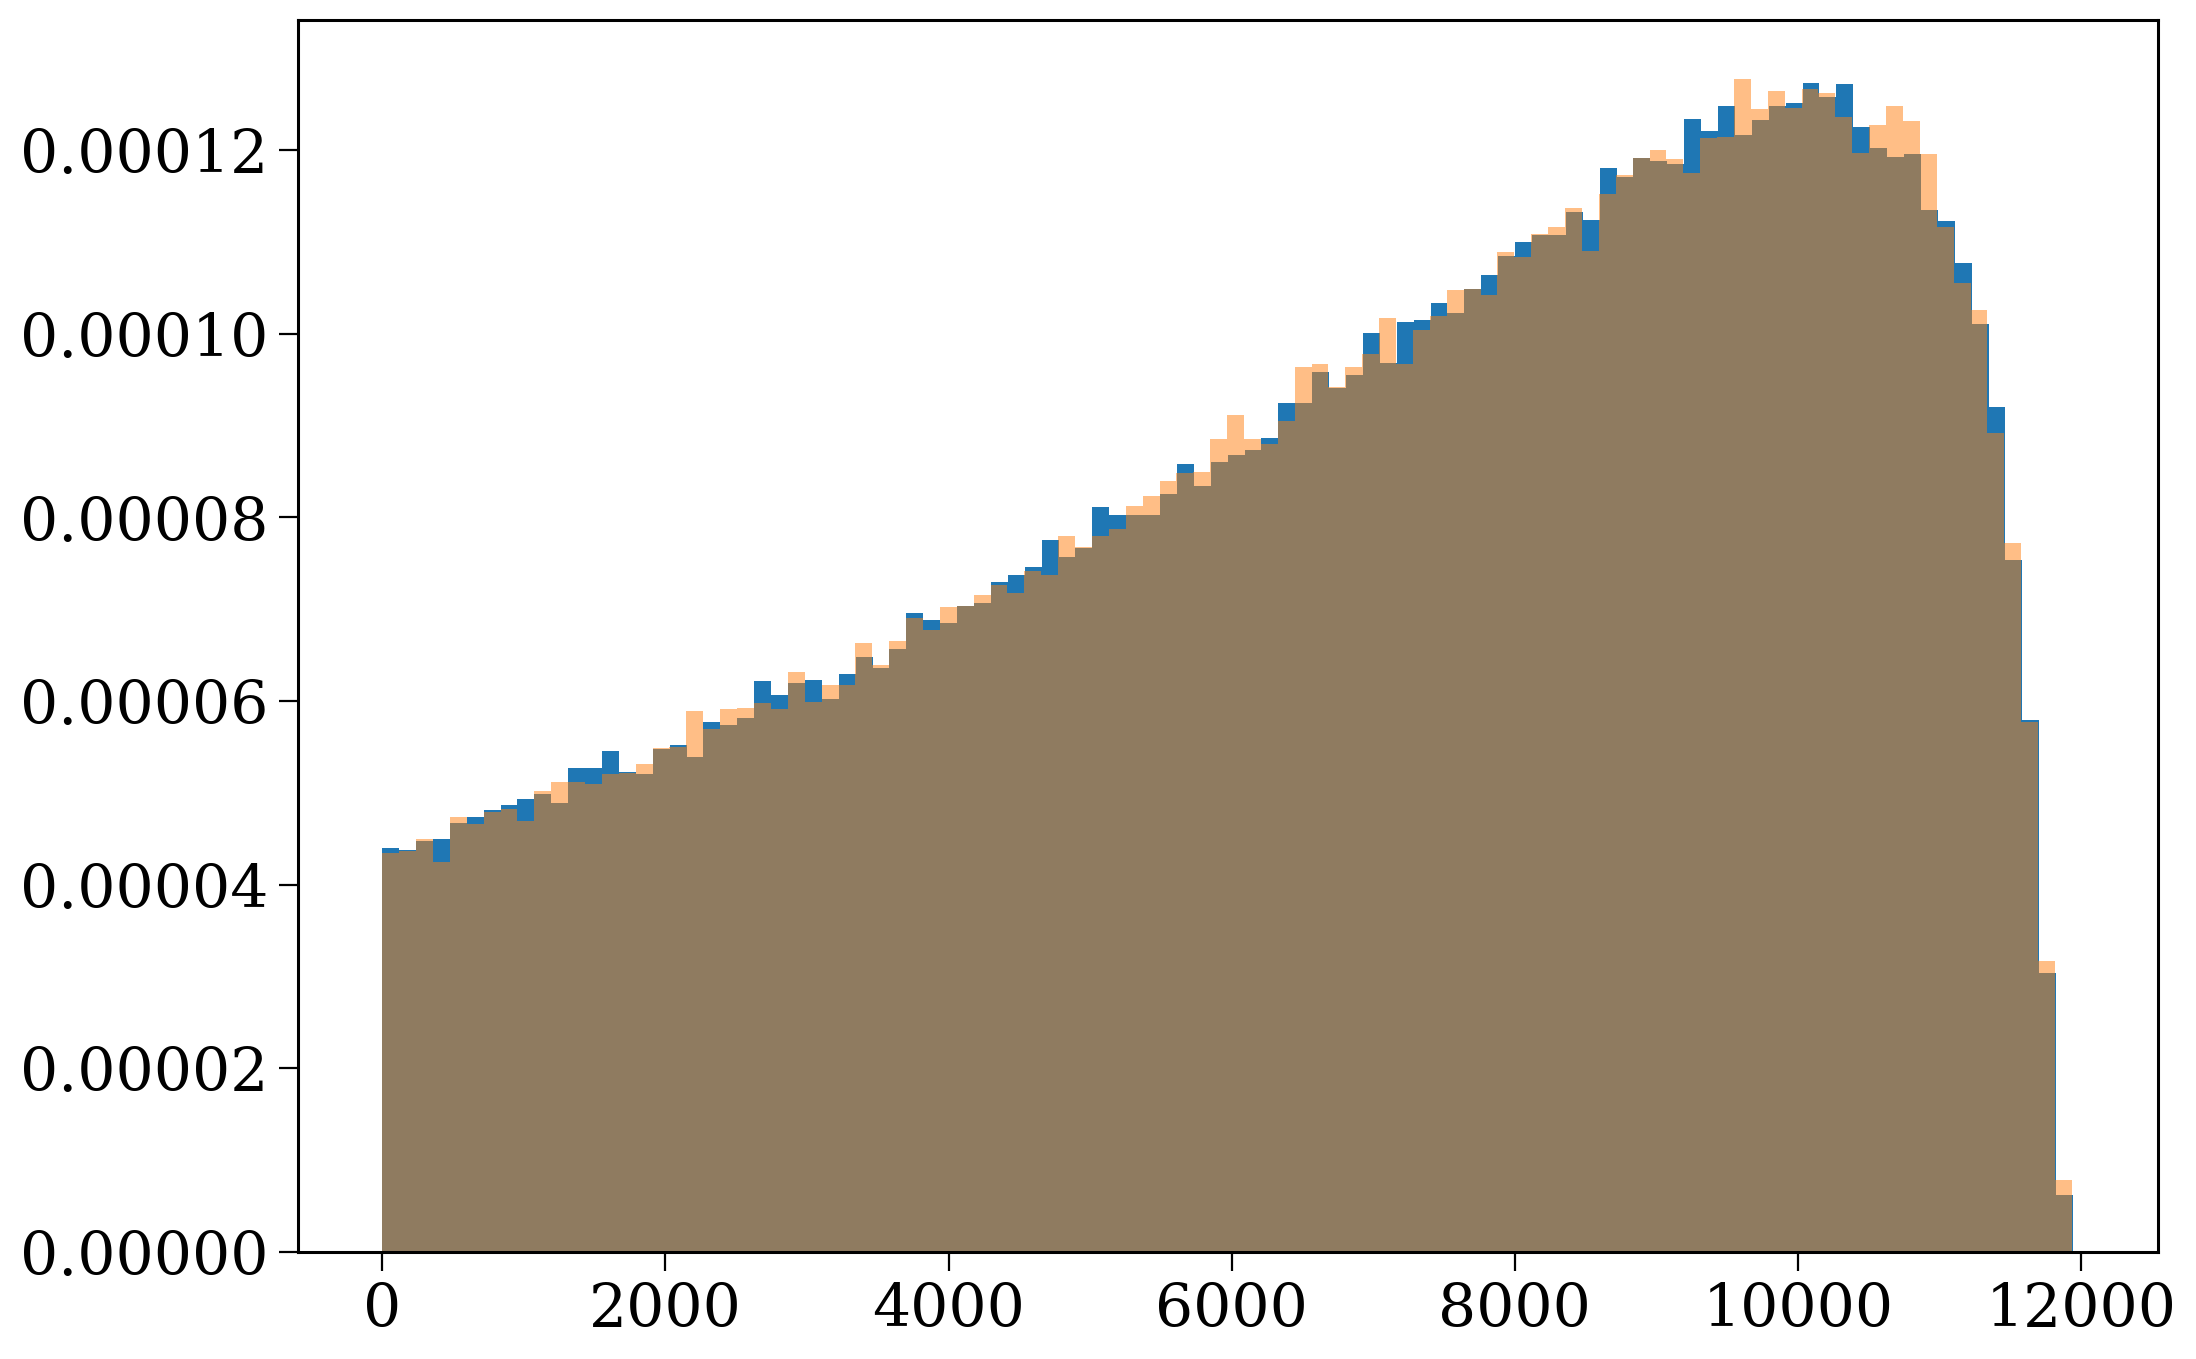

In [73]:
# bins = np.geomspace(4, 150, 100)
bins = 100

plt.hist(old_template.initC["tphysf"], bins=bins, density=True);
plt.hist(new_template.initC["tphysf"], bins=bins, alpha=0.5, density=True);
# plt.xscale("log")